In [25]:
# === EĞİTİM SONU KAYIT HÜCRESİ ===
from pathlib import Path
import json
from src.paths import MODELS_DIR, CLASS_NAMES_DIR, OUTPUTS_DIR

# klasörleri garanti et
MODELS_DIR.mkdir(parents=True, exist_ok=True)
CLASS_NAMES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# 1) Modeli kaydet
model_path = MODELS_DIR / "plant_model_250classes_local.keras"
model.save(model_path)
print("Model kaydedildi  ->", model_path)

# 2) Class isimlerini kaydet
class_names_path = CLASS_NAMES_DIR / "class_names.json"
with open(class_names_path, "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)
print("Class names kaydedildi ->", class_names_path)

# 3) History (loss/acc geçmişi) kaydet
history_path = OUTPUTS_DIR / "history_plant_model_250classes_local.json"
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history.history, f, ensure_ascii=False, indent=2)
print("History kaydedildi ->", history_path)

Model kaydedildi  -> C:\Users\HP\plant_project\plant_project\models\plant_model_250classes_local.keras
Class names kaydedildi -> C:\Users\HP\plant_project\plant_project\class_names\class_names.json
History kaydedildi -> C:\Users\HP\plant_project\plant_project\outputs\history_plant_model_250classes_local.json


In [ ]:
from tensorflow import keras
import json
from src.paths import MODELS_DIR, CLASS_NAMES_DIR

model = keras.models.load_model(MODELS_DIR / "plant_model_250classes_local.keras")

with open(CLASS_NAMES_DIR / "class_names.json", "r", encoding="utf-8") as f:
    class_names = json.load(f)

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src klasörü var mı?:", (PROJECT_ROOT / "src").exists())

PROJECT_ROOT: C:\Users\HP\plant_project\plant_project
src klasörü var mı?: True


In [5]:
import random, shutil
from pathlib import Path
from src.paths import DATA_DIR

random.seed(42)

SRC_ROOT = DATA_DIR / "leafsnap_subset_50" / "images" / "field"
OUT_ROOT = DATA_DIR / "leafsnap_split"

print("SRC_ROOT:", SRC_ROOT)
print("SRC_ROOT exists:", SRC_ROOT.exists())

train_dir = OUT_ROOT / "train"
val_dir = OUT_ROOT / "val"
test_dir = OUT_ROOT / "test"

for d in [train_dir, val_dir, test_dir]:
    d.mkdir(parents=True, exist_ok=True)

class_dirs = [p for p in SRC_ROOT.iterdir() if p.is_dir()]
print("Kaç sınıf klasörü var:", len(class_dirs))

train_count = val_count = test_count = 0

for cdir in class_dirs:
    imgs = list(cdir.glob("*.jpg"))
    print("Sınıf:", cdir.name, "görüntü sayısı:", len(imgs))  # debug satırı

    random.shuffle(imgs)
    n = len(imgs)

    train_split = int(n * 0.7)
    val_split = int(n * 0.15)

    train_imgs = imgs[:train_split]
    val_imgs = imgs[train_split:train_split+val_split]
    test_imgs = imgs[train_split+val_split:]

    for img in train_imgs:
        dst = train_dir / cdir.name
        dst.mkdir(exist_ok=True)
        shutil.copy2(img, dst / img.name)
        train_count += 1

    for img in val_imgs:
        dst = val_dir / cdir.name
        dst.mkdir(exist_ok=True)
        shutil.copy2(img, dst / img.name)
        val_count += 1

    for img in test_imgs:
        dst = test_dir / cdir.name
        dst.mkdir(exist_ok=True)
        shutil.copy2(img, dst / img.name)
        test_count += 1

print("Train görüntü:", train_count)
print("Validation görüntü:", val_count)
print("Test görüntü:", test_count)
print("Toplam:", train_count + val_count + test_count)

SRC_ROOT: C:\Users\HP\plant_project\plant_project\data\leafsnap_subset_50\images\field
SRC_ROOT exists: True
Kaç sınıf klasörü var: 50
Sınıf: abies_concolor görüntü sayısı: 51
Sınıf: acer_palmatum görüntü sayısı: 80
Sınıf: aesculus_pavi görüntü sayısı: 80
Sınıf: asimina_triloba görüntü sayısı: 49
Sınıf: broussonettia_papyrifera görüntü sayısı: 54
Sınıf: carya_cordiformis görüntü sayısı: 52
Sınıf: carya_glabra görüntü sayısı: 77
Sınıf: carya_tomentosa görüntü sayısı: 53
Sınıf: catalpa_speciosa görüntü sayısı: 72
Sınıf: cedrus_atlantica görüntü sayısı: 79
Sınıf: chamaecyparis_pisifera görüntü sayısı: 52
Sınıf: cladrastis_lutea görüntü sayısı: 51
Sınıf: cornus_florida görüntü sayısı: 51
Sınıf: cryptomeria_japonica görüntü sayısı: 80
Sınıf: eucommia_ulmoides görüntü sayısı: 71
Sınıf: fraxinus_nigra görüntü sayısı: 80
Sınıf: juglans_cinerea görüntü sayısı: 80
Sınıf: juniperus_virginiana görüntü sayısı: 65
Sınıf: koelreuteria_paniculata görüntü sayısı: 74
Sınıf: liriodendron_tulipifera görün

In [16]:
#images/field içindeki tüm sınıfları buldu, her sınıfta kaç foto var saydı, en çok/en az olanları yazdırdı.
from pathlib import Path
from collections import Counter
from pathlib import Path

DATA_ROOT = Path("..") / "data" / "leafsnap-dataset" / "dataset"
FIELD_DIR = DATA_ROOT / "images" / "field"

print("FIELD_DIR var mı?:", FIELD_DIR.exists())
print("FIELD_DIR:", FIELD_DIR)

# sınıflar (klasör isimleri)
class_dirs = sorted([p for p in FIELD_DIR.iterdir() if p.is_dir()])
print("Toplam sınıf sayısı:", len(class_dirs))
print("İlk 10 sınıf:", [p.name for p in class_dirs[:10]])

# sınıf başına görüntü sayısı
counts = Counter()
for cdir in class_dirs:
    n = 0
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        n += len(list(cdir.glob(ext)))
    counts[cdir.name] = n

total_imgs = sum(counts.values())
print("Toplam görüntü:", total_imgs)

print("\nEn çok görüntü olan 10 sınıf:")
for name, n in counts.most_common(10):
    print(name, n)

print("\nEn az görüntü olan 10 sınıf:")
for name, n in counts.most_common()[-10:]:
    print(name, n)

FIELD_DIR var mı?: True
FIELD_DIR: ..\data\leafsnap-dataset\dataset\images\field
Toplam sınıf sayısı: 184
İlk 10 sınıf: ['abies_concolor', 'abies_nordmanniana', 'acer_campestre', 'acer_ginnala', 'acer_griseum', 'acer_negundo', 'acer_palmatum', 'acer_pensylvanicum', 'acer_platanoides', 'acer_pseudoplatanus']
Toplam görüntü: 7719

En çok görüntü olan 10 sınıf:
prunus_virginiana 183
prunus_sargentii 168
ulmus_pumila 145
cryptomeria_japonica 132
styrax_japonica 108
quercus_muehlenbergii 106
aesculus_pavi 101
juglans_cinerea 97
acer_palmatum 92
fraxinus_nigra 85

En az görüntü olan 10 sınıf:
quercus_alba 15
quercus_palustris 15
quercus_phellos 15
tilia_americana 15
tilia_europaea 15
ulmus_americana 15
morus_alba 14
crataegus_crus-galli 13
betula_lenta 11
pinus_thunbergii 10


In [17]:
#Leafsnap field’den 50 sınıf seçti, her sınıftan en fazla 80 foto alarak 
#/kaggle/working/leafsnap_subset_50/... içine kopyaladı. yani subset oluşturma işlemini yaptık.
from pathlib import Path
from collections import Counter
import random, shutil

random.seed(42)

from pathlib import Path
from src.paths import DATA_DIR

DATA_ROOT = DATA_DIR / "leafsnap-dataset" / "dataset"
FIELD_DIR = DATA_ROOT / "images" / "field"

OUT_ROOT = DATA_DIR / "leafsnap_subset_50"
OUT_FIELD = OUT_ROOT / "images" / "field"

# temiz başla
if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)
OUT_FIELD.mkdir(parents=True, exist_ok=True)

# sınıf başına sayım
class_dirs = sorted([p for p in FIELD_DIR.iterdir() if p.is_dir()])
counts = Counter()

for cdir in class_dirs:
    n = 0
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        n += len(list(cdir.glob(ext)))
    counts[cdir.name] = n

min_images_per_class = 30
K = 50
cap_per_class = 80

eligible = [c for c, n in counts.items() if n >= min_images_per_class]
eligible_sorted = sorted(eligible, key=lambda c: counts[c], reverse=True)

if len(eligible_sorted) < K:
    raise ValueError(f"Yeterli sınıf yok. Eligible={len(eligible_sorted)} ama K={K}")

chosen_classes = eligible_sorted[:K]
print("Seçilen sınıf sayısı:", len(chosen_classes))
print("Seçilen ilk 10 sınıf:", chosen_classes[:10])
print("Seçilen sınıfların (orijinal) min/max görüntü sayısı:",
      min(counts[c] for c in chosen_classes), max(counts[c] for c in chosen_classes))

# KOPYALAMA
total_copied = 0
for cls in chosen_classes:
    src_dir = FIELD_DIR / cls
    dst_dir = OUT_FIELD / cls
    dst_dir.mkdir(parents=True, exist_ok=True)

    imgs = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        imgs.extend(list(src_dir.glob(ext)))

    random.shuffle(imgs)
    imgs = imgs[:min(cap_per_class, len(imgs))]

    for img_path in imgs:
        shutil.copy2(img_path, dst_dir / img_path.name)
    total_copied += len(imgs)

print("Subset oluşturuldu ✅")
print("OUT_ROOT:", OUT_ROOT)
print("Toplam kopyalanan görüntü:", total_copied)

# hızlı kontrol
subset_class_dirs = sorted([p for p in OUT_FIELD.iterdir() if p.is_dir()])
print("Subset sınıf sayısı:", len(subset_class_dirs))
print("Örnek subset sınıfları:", [p.name for p in subset_class_dirs[:10]])

Seçilen sınıf sayısı: 50
Seçilen ilk 10 sınıf: ['prunus_virginiana', 'prunus_sargentii', 'ulmus_pumila', 'cryptomeria_japonica', 'styrax_japonica', 'quercus_muehlenbergii', 'aesculus_pavi', 'juglans_cinerea', 'acer_palmatum', 'fraxinus_nigra']
Seçilen sınıfların (orijinal) min/max görüntü sayısı: 49 183
Subset oluşturuldu ✅
OUT_ROOT: C:\Users\HP\plant_project\plant_project\data\leafsnap_subset_50
Toplam kopyalanan görüntü: 3115
Subset sınıf sayısı: 50
Örnek subset sınıfları: ['abies_concolor', 'acer_palmatum', 'aesculus_pavi', 'asimina_triloba', 'broussonettia_papyrifera', 'carya_cordiformis', 'carya_glabra', 'carya_tomentosa', 'catalpa_speciosa', 'cedrus_atlantica']


In [18]:
#50 sınıfın her birini aldı görüntüleri karıştırdı %70 train %15 val %15 test olarak böldü.
import random, shutil
from pathlib import Path
from src.paths import DATA_DIR

random.seed(42)

SRC_ROOT = DATA_DIR / "leafsnap_subset_50" / "images" / "field"
OUT_ROOT = DATA_DIR / "leafsnap_split"

print("SRC_ROOT:", SRC_ROOT)
print("SRC_ROOT exists:", SRC_ROOT.exists())

train_dir = OUT_ROOT / "train"
val_dir = OUT_ROOT / "val"
test_dir = OUT_ROOT / "test"

# klasörleri oluştur
for d in [train_dir, val_dir, test_dir]:
    d.mkdir(parents=True, exist_ok=True)

class_dirs = [p for p in SRC_ROOT.iterdir() if p.is_dir()]
print("Kaç sınıf klasörü var:", len(class_dirs))

train_count = 0
val_count = 0
test_count = 0

for cdir in class_dirs:
    imgs = list(cdir.glob("*.jpg"))
    random.shuffle(imgs)

    n = len(imgs)

    train_split = int(n * 0.7)
    val_split = int(n * 0.15)

    train_imgs = imgs[:train_split]
    val_imgs = imgs[train_split:train_split+val_split]
    test_imgs = imgs[train_split+val_split:]

    for img in train_imgs:
        dst = train_dir / cdir.name
        dst.mkdir(exist_ok=True)
        shutil.copy2(img, dst / img.name)
        train_count += 1

    for img in val_imgs:
        dst = val_dir / cdir.name
        dst.mkdir(exist_ok=True)
        shutil.copy2(img, dst / img.name)
        val_count += 1

    for img in test_imgs:
        dst = test_dir / cdir.name
        dst.mkdir(exist_ok=True)
        shutil.copy2(img, dst / img.name)
        test_count += 1

print("Train görüntü:", train_count)
print("Validation görüntü:", val_count)
print("Test görüntü:", test_count)
print("Toplam:", train_count + val_count + test_count)

SRC_ROOT: C:\Users\HP\plant_project\plant_project\data\leafsnap_subset_50\images\field
SRC_ROOT exists: True
Kaç sınıf klasörü var: 50
Train görüntü: 2163
Validation görüntü: 444
Test görüntü: 508
Toplam: 3115


In [19]:
#MobileNetV2’yi hazır alacağız (önceden eğitilmiş) Gövdeyi donduracağız (freeze)
#Sadece en sona “bizim 50 sınıfımız için” yeni bir katman ekleyip eğiteceğiz
#image_dataset_from_directory: klasör yapısından otomatik dataset oluşturdu
#MobileNetV2(weights="imagenet"): hazır modeli indirdi base_model.trainable = False: dondurdu
#(yani öğrenmesini kapattı) Dense(num_classes): senin 50 sınıfın için yeni çıkış katmanı ekledi
#8 epoch eğitim yaptı ve test accuracy bastı
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from src.paths import DATA_DIR as ROOT_DATA_DIR  # <-- ek

DATA_DIR = ROOT_DATA_DIR / "leafsnap_split"      # <-- değişen satır
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "val",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Sınıf sayısı:", num_classes)
print("İlk 10 sınıf:", class_names[:10])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

EPOCHS = 8
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

Found 2163 files belonging to 50 classes.
Found 444 files belonging to 50 classes.
Found 508 files belonging to 50 classes.
Sınıf sayısı: 50
İlk 10 sınıf: ['abies_concolor', 'acer_palmatum', 'aesculus_pavi', 'asimina_triloba', 'broussonettia_papyrifera', 'carya_cordiformis', 'carya_glabra', 'carya_tomentosa', 'catalpa_speciosa', 'cedrus_atlantica']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        64,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,322,034 (8.86 MB)

 Trainable params: 64,050 (250.20 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 27s 324ms/step - accuracy: 0.4290 - loss: 2.2670 - val_accuracy: 0.7387 - val_loss: 1.0120
Epoch 2/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 300ms/step - accuracy: 0.8100 - loss: 0.7225 - val_accuracy: 0.8468 - val_loss: 0.6439
Epoch 3/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 298ms/step - accuracy: 0.8659 - loss: 0.4980 - val_accuracy: 0.8851 - val_loss: 0.4811
Epoch 4/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 298ms/step - accuracy: 0.8997 - loss: 0.3617 - val_accuracy: 0.8829 - val_loss: 0.4268
Epoch 5/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 21s 301ms/step - accuracy: 0.9200 - loss: 0.3015 - val_accuracy: 0.8919 - val_loss: 0.3834
Epoch 6/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 22s 311ms/step - accuracy: 0.9256 - loss: 0.2600 - val_accuracy: 0.9099 - val_loss: 0.3569
Epoch 7/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 32s 471ms/step - accuracy: 0.9376 - loss: 0.2221 - val_accuracy: 0.8941 - val_loss: 0.3262
Epoch 8/8
68/68 ━━━━━━━━━━━━━━━━━━━━ 48s 687ms/step - accuracy: 0.9491 - loss: 0.1938 - val_accuracy: 0.

In [20]:
# Fine tuning başlıyor MobileNet’i açtı base_model.trainable = True
# İlk katmanları tekrar kapattı fine_tune_at = len(base_model.layers) - 30
#Yani sadece son 30 katman öğreniyor. Learning rate düşürdük 1e-3 → 1e-5 Çünkü artık ince ayar yapıyoruz.

base_model.trainable = True

# sadece üst katmanları aç
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

FINE_EPOCHS = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_EPOCHS
)

test_loss, test_acc = model.evaluate(test_ds)

print("Fine tuned test accuracy:", test_acc)

Epoch 1/5


68/68 ━━━━━━━━━━━━━━━━━━━━ 31s 377ms/step - accuracy: 0.7272 - loss: 0.9132 - val_accuracy: 0.9189 - val_loss: 0.2889
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 359ms/step - accuracy: 0.8447 - loss: 0.5326 - val_accuracy: 0.9009 - val_loss: 0.2901
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 364ms/step - accuracy: 0.8974 - loss: 0.3960 - val_accuracy: 0.8964 - val_loss: 0.2895
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 25s 363ms/step - accuracy: 0.9214 - loss: 0.3141 - val_accuracy: 0.9054 - val_loss: 0.2823
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 26s 372ms/step - accuracy: 0.9251 - loss: 0.2737 - val_accuracy: 0.9077 - val_loss: 0.2768
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - accuracy: 0.8720 - loss: 0.3215
Fine tuned test accuracy: 0.8720472455024719


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step
Classification Report:

                              precision    recall  f1-score   support

              abies_concolor       1.00      1.00      1.00         9
               acer_palmatum       1.00      1.00      1.00        12
               aesculus_pavi       1.00      0.92      0.96        12
             asimina_triloba       1.00      0.75      0.86         8
 

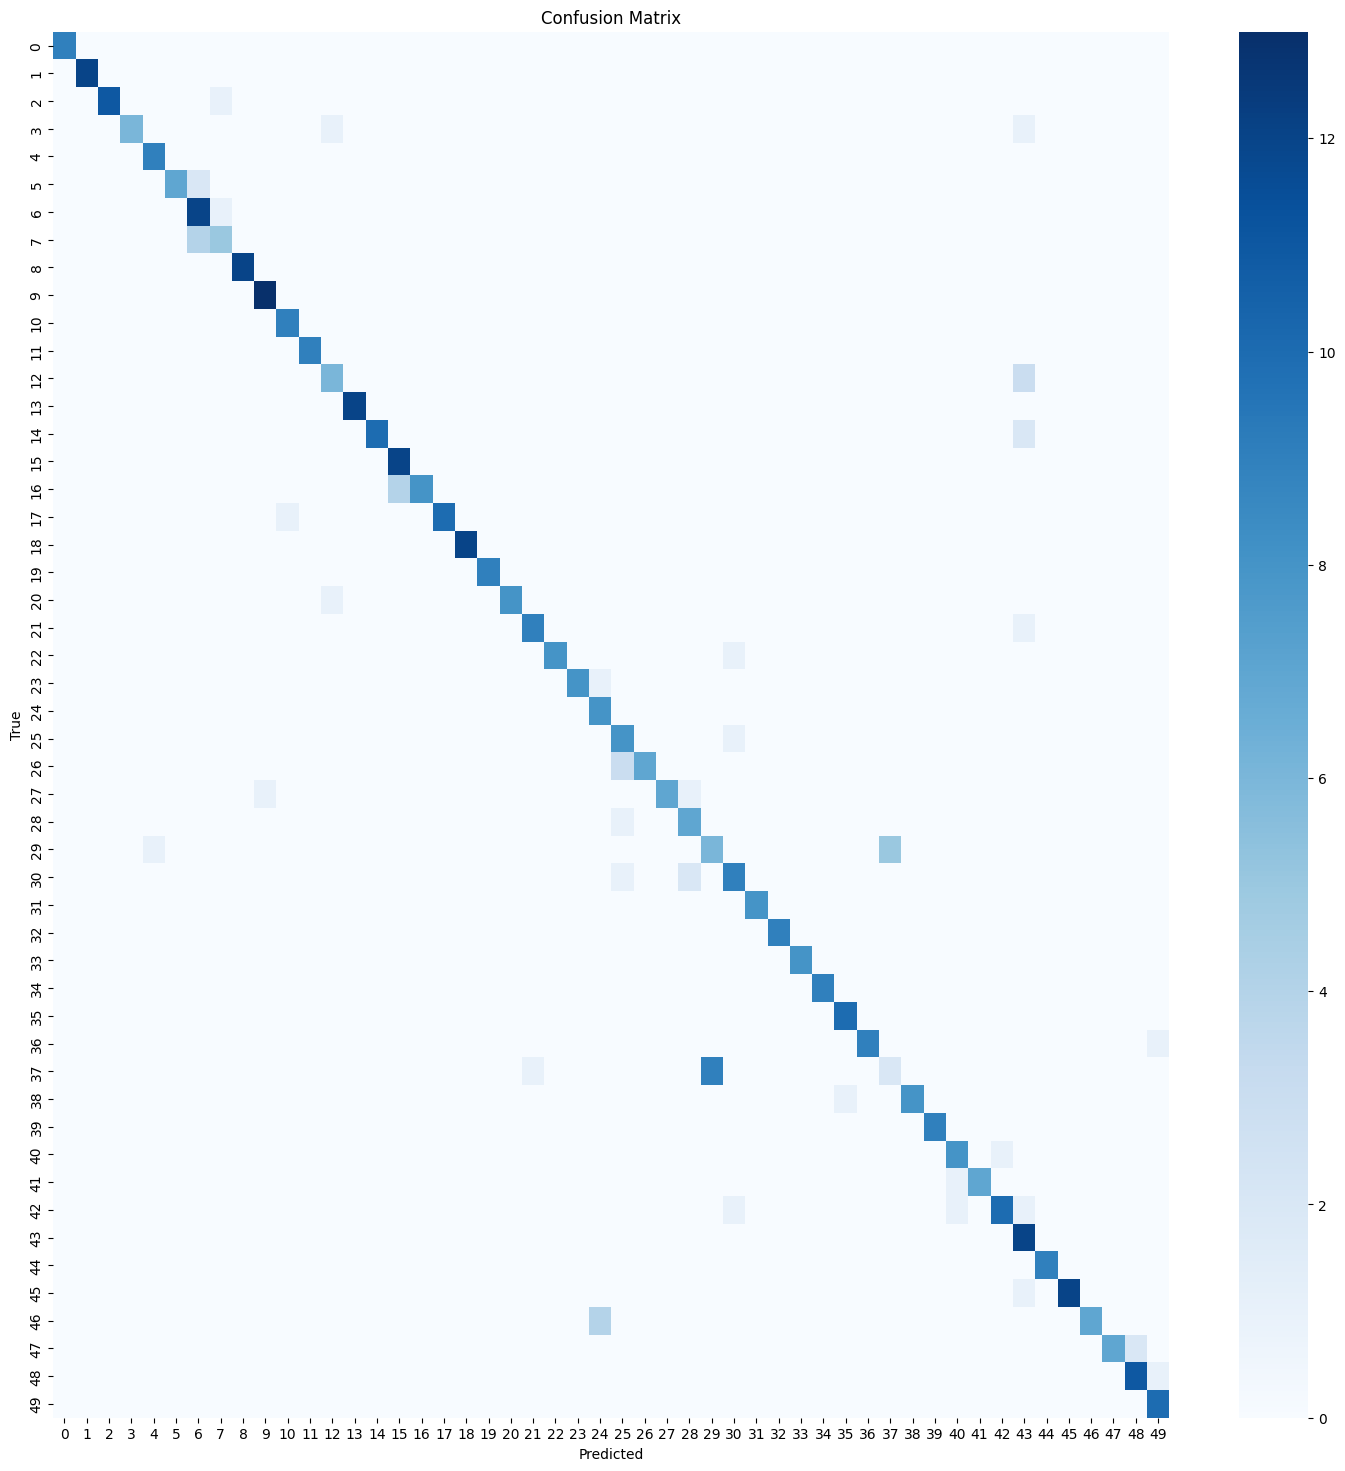

In [21]:
#Şimdi modelin nerede hata yaptığını, hangi türleri karıştırdığını görmemiz gerekiyor.Bu Confusion Matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)
    
    y_pred.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18,18))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [23]:
import tensorflow as tf
from pathlib import Path
from src.paths import DATA_DIR as ROOT_DATA_DIR  # ek

DATA_DIR = ROOT_DATA_DIR / "leafsnap_split"      # değişti
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_dir = DATA_DIR / "test"

print("test_dir:", test_dir)
print("test_dir exists:", test_dir.exists())

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,  # önemli: sıralama bozulmasın
)

class_names = test_ds.class_names
print("Sınıf sayısı:", len(class_names))
print("İlk 10 sınıf:", class_names[:10])

test_dir: C:\Users\HP\plant_project\plant_project\data\leafsnap_split\test
test_dir exists: True
Found 508 files belonging to 50 classes.
Sınıf sayısı: 50
İlk 10 sınıf: ['abies_concolor', 'acer_palmatum', 'aesculus_pavi', 'asimina_triloba', 'broussonettia_papyrifera', 'carya_cordiformis', 'carya_glabra', 'carya_tomentosa', 'catalpa_speciosa', 'cedrus_atlantica']


Toplam test görüntü: 508


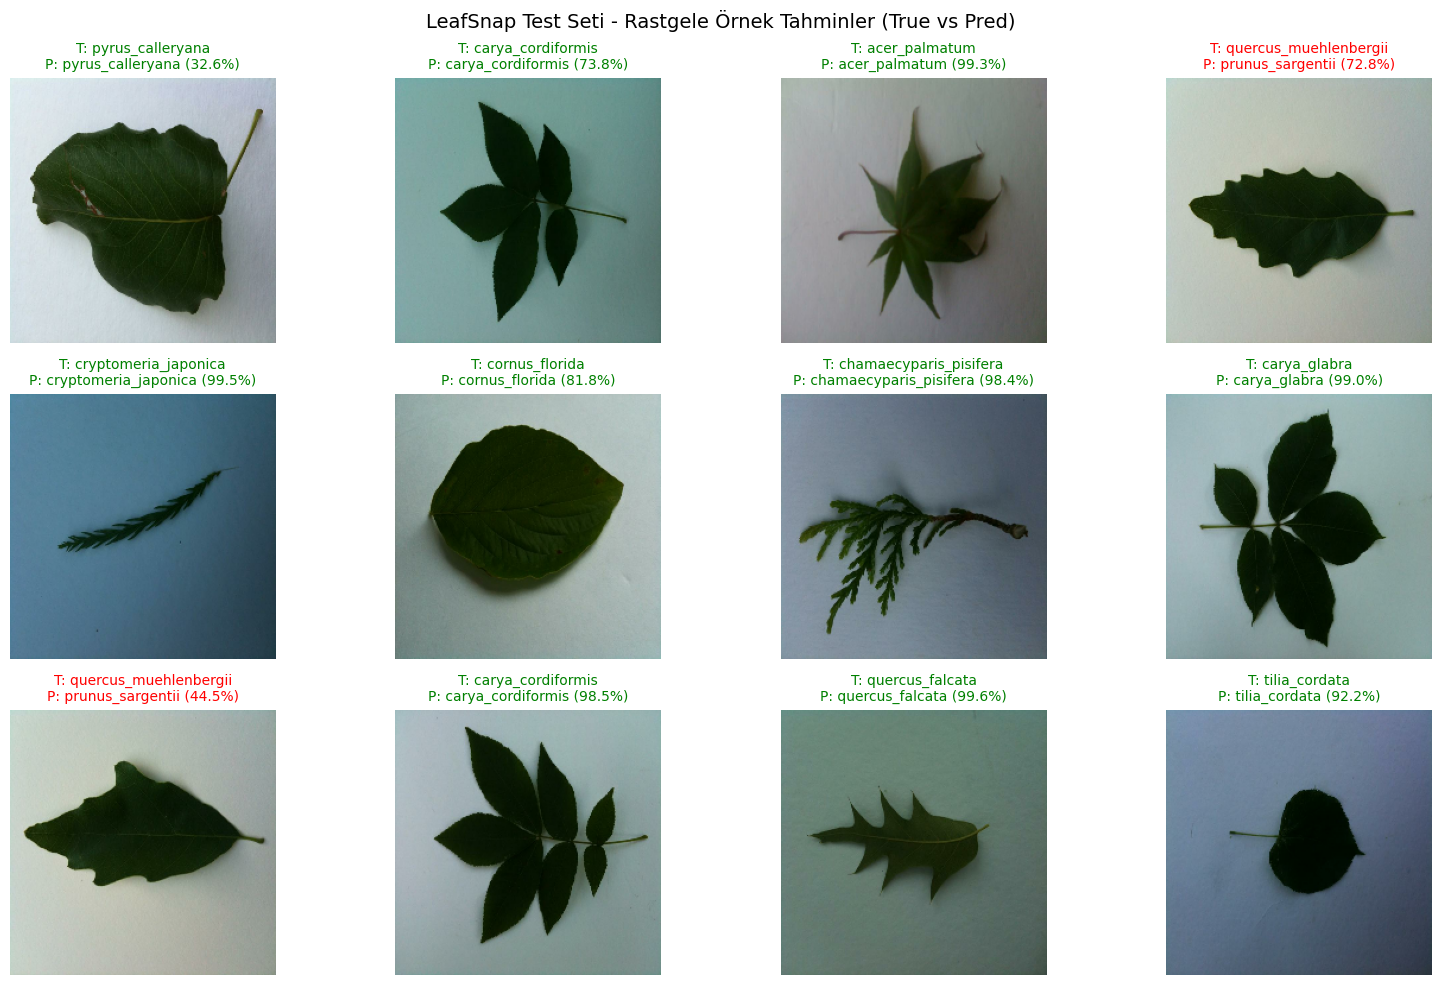

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import random

# test setindeki tüm görüntüleri ve etiketleri RAM'e alalım (508 image -> rahat)
images = []
labels = []

for batch_imgs, batch_labels in test_ds:
    images.append(batch_imgs.numpy())
    labels.append(batch_labels.numpy())

images = np.concatenate(images, axis=0)
labels = np.concatenate(labels, axis=0)

print("Toplam test görüntü:", len(images))

# rastgele 12 örnek
random.seed(42)
idxs = random.sample(range(len(images)), 12)

sample_imgs = images[idxs]
sample_labels = labels[idxs].astype(int)

# model tahminleri
probs = model.predict(sample_imgs, verbose=0)  # model değişkenin adı "model" değilse söyle
pred_ids = np.argmax(probs, axis=1)
conf = np.max(probs, axis=1)

# çizim
plt.figure(figsize=(16, 10))
for i, idx in enumerate(idxs):
    true_id = sample_labels[i]
    pred_id = pred_ids[i]
    ok = (true_id == pred_id)

    true_name = class_names[true_id]
    pred_name = class_names[pred_id]
    c = conf[i] * 100

    plt.subplot(3, 4, i+1)
    plt.imshow(sample_imgs[i].astype("uint8"))
    plt.axis("off")
    plt.title(
        f"T: {true_name}\nP: {pred_name} ({c:.1f}%)",
        color=("green" if ok else "red"),
        fontsize=10
    )

plt.suptitle("LeafSnap Test Seti - Rastgele Örnek Tahminler (True vs Pred)", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
#yeni datasetteki sınıf sayısını vs bul
from pathlib import Path
import os, glob

from src.paths import DATA_DIR

PLANTNET_ROOT = DATA_DIR / "plantnet_300K"

train_dir = PLANTNET_ROOT / "images_train"
val_dir   = PLANTNET_ROOT / "images_val"
test_dir  = PLANTNET_ROOT / "images_test"

print("PLANTNET_ROOT exists:", PLANTNET_ROOT.exists())
print("Train exists:", train_dir.exists())
print("Val exists:", val_dir.exists())
print("Test exists:", test_dir.exists())

# kaç sınıf klasörü var?
if train_dir.exists():
    classes = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
    print("Train class count:", len(classes))
    print("First 10 classes:", classes[:10])

    # bir sınıftan örnek kaç jpg var?
    if classes:
        sample_class = train_dir / classes[0]
        jpg_count = len(list(sample_class.rglob("*.jpg")))
        print("Sample class:", classes[0], "jpg:", jpg_count)

PLANTNET_ROOT exists: True
Train exists: True
Val exists: True
Test exists: True
Train class count: 1081
First 10 classes: ['1355868', '1355920', '1355932', '1355936', '1355937', '1355955', '1355959', '1355961', '1355978', '1355990']
Sample class: 1355868 jpg: 335


In [3]:
#subset cıkarıp workıng altına kopyalaıp eafsnap ıle bırlestırme ıslemı yapıyor
from pathlib import Path
import random
import shutil

random.seed(42)

# -------------------------
# YOLLAR
# -------------------------
from src.paths import DATA_DIR

LEAFSNAP_SPLIT = DATA_DIR / "leafsnap_split"
PLANTNET_ROOT  = DATA_DIR / "plantnet_300K"
PLANTNET_TRAIN = PLANTNET_ROOT / "images_train"
PLANTNET_VAL   = PLANTNET_ROOT / "images_val"
PLANTNET_TEST  = PLANTNET_ROOT / "images_test"

OUT = DATA_DIR / "combined_split"
OUT_TRAIN = OUT / "train"
OUT_VAL   = OUT / "val"
OUT_TEST  = OUT / "test"

# -------------------------
# TEMİZLE
# -------------------------
if OUT.exists():
    shutil.rmtree(OUT)

OUT_TRAIN.mkdir(parents=True, exist_ok=True)
OUT_VAL.mkdir(parents=True, exist_ok=True)
OUT_TEST.mkdir(parents=True, exist_ok=True)

# -------------------------
# PlantNet sınıf seçimi
# -------------------------
def count_images_in_classdir(cdir: Path):
    count = 0
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        count += len(list(cdir.glob(ext)))
    return count

plantnet_class_dirs = [p for p in PLANTNET_TRAIN.iterdir() if p.is_dir()]
counts = {p.name: count_images_in_classdir(p) for p in plantnet_class_dirs}

MIN_PER_CLASS = 50
eligible = [cls for cls, n in counts.items() if n >= MIN_PER_CLASS]

N_SELECT = 200
selected_classes = random.sample(eligible, k=N_SELECT)

print("PlantNet total classes:", len(counts))
print("Eligible classes:", len(eligible))
print("Selected classes:", len(selected_classes))

# -------------------------
# KOPYALAMA (SINIRLI)
# -------------------------
MAX_TRAIN_PER_CLASS = 80
MAX_VAL_PER_CLASS   = 20
MAX_TEST_PER_CLASS  = 20

def copy_limited(src_root: Path, dst_root: Path, class_names, prefix: str, max_per_class: int):
    copied_files = 0
    copied_classes = 0

    for cls in class_names:
        src_cls = src_root / cls
        if not src_cls.exists():
            continue

        dst_cls = dst_root / f"{prefix}__{cls}"
        dst_cls.mkdir(parents=True, exist_ok=True)

        imgs = []
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            imgs.extend(list(src_cls.glob(ext)))

        random.shuffle(imgs)
        imgs = imgs[:max_per_class]

        for img in imgs:
            shutil.copy2(img, dst_cls / img.name)
            copied_files += 1

        if len(imgs) > 0:
            copied_classes += 1

    return copied_files, copied_classes

# PlantNet kopyala
pn_train_files, pn_train_classes = copy_limited(PLANTNET_TRAIN, OUT_TRAIN, selected_classes, "plantnet", MAX_TRAIN_PER_CLASS)
pn_val_files,   pn_val_classes   = copy_limited(PLANTNET_VAL,   OUT_VAL,   selected_classes, "plantnet", MAX_VAL_PER_CLASS)
pn_test_files,  pn_test_classes  = copy_limited(PLANTNET_TEST,  OUT_TEST,  selected_classes, "plantnet", MAX_TEST_PER_CLASS)

print("\nPlantNet copied:")
print(" train files:", pn_train_files, "| classes:", pn_train_classes)
print(" val files  :", pn_val_files,   "| classes:", pn_val_classes)
print(" test files :", pn_test_files,  "| classes:", pn_test_classes)

# -------------------------
# Leafsnap'i TAM ekle
# -------------------------
def copy_all(src_root: Path, dst_root: Path, class_names, prefix: str):
    copied_files = 0
    copied_classes = 0

    for cls in class_names:
        src_cls = src_root / cls
        if not src_cls.exists():
            continue

        dst_cls = dst_root / f"{prefix}__{cls}"
        dst_cls.mkdir(parents=True, exist_ok=True)

        count_before = copied_files

        for ext in ("*.jpg", "*.jpeg", "*.png"):
            for img in src_cls.glob(ext):
                shutil.copy2(img, dst_cls / img.name)
                copied_files += 1

        if copied_files > count_before:
            copied_classes += 1

    return copied_files, copied_classes

leaf_classes = [p.name for p in (LEAFSNAP_SPLIT / "train").iterdir() if p.is_dir()]

ls_train_files, ls_train_classes = copy_all(LEAFSNAP_SPLIT / "train", OUT_TRAIN, leaf_classes, "leafsnap")
ls_val_files,   ls_val_classes   = copy_all(LEAFSNAP_SPLIT / "val",   OUT_VAL,   leaf_classes, "leafsnap")
ls_test_files,  ls_test_classes  = copy_all(LEAFSNAP_SPLIT / "test",  OUT_TEST,  leaf_classes, "leafsnap")

print("\nLeafsnap copied:")
print(" train files:", ls_train_files, "| classes:", ls_train_classes)
print(" val files  :", ls_val_files,   "| classes:", ls_val_classes)
print(" test files :", ls_test_files,  "| classes:", ls_test_classes)

# -------------------------
# SON KONTROL
# -------------------------
def list_class_dirs(split_dir: Path):
    return sorted([p.name for p in split_dir.iterdir() if p.is_dir()])

train_classes = list_class_dirs(OUT_TRAIN)
val_classes   = list_class_dirs(OUT_VAL)
test_classes  = list_class_dirs(OUT_TEST)

print("\nCombined class counts:")
print(" train:", len(train_classes))
print(" val  :", len(val_classes))
print(" test :", len(test_classes))

print("\nSame class set across splits?:", set(train_classes) == set(val_classes) == set(test_classes))
print("OUT:", OUT)

PlantNet total classes: 1081
Eligible classes: 397
Selected classes: 200

PlantNet copied:
 train files: 15491 | classes: 200
 val files  : 1275 | classes: 71
 test files : 3272 | classes: 200

Leafsnap copied:
 train files: 2163 | classes: 50
 val files  : 444 | classes: 50
 test files : 508 | classes: 50

Combined class counts:
 train: 250
 val  : 121
 test : 250

Same class set across splits?: False
OUT: C:\Users\HP\plant_project\plant_project\data\combined_split


In [5]:
#Combined_split/train-val-test klasörlerini yükledi 250 sınıfı otomatik algıladı
#MobileNetV2 tabanını kullandı tabanı dondurdu (base_model.trainable = False) 
#Yeni 250 sınıflık çıkış katmanı kurdu modeli eğitti test doğruluğunu verdi
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from src.paths import DATA_DIR as ROOT_DATA_DIR  # <-- ek

# -------------------------
# DATASET YOLU
# -------------------------
DATA_DIR = ROOT_DATA_DIR / "combined_split"      # <-- değişti

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "val",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Toplam sınıf sayısı:", num_classes)
print("İlk 10 sınıf:", class_names[:10])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

EPOCHS = 8

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

Found 17654 files belonging to 250 classes.
Found 1719 files belonging to 121 classes.
Found 3780 files belonging to 250 classes.
Toplam sınıf sayısı: 250
İlk 10 sınıf: ['leafsnap__abies_concolor', 'leafsnap__acer_palmatum', 'leafsnap__aesculus_pavi', 'leafsnap__asimina_triloba', 'leafsnap__broussonettia_papyrifera', 'leafsnap__carya_cordiformis', 'leafsnap__carya_glabra', 'leafsnap__carya_tomentosa', 'leafsnap__catalpa_speciosa', 'leafsnap__cedrus_atlantica']


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 250)            │       320,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,578,234 (9.84 MB)

 Trainable params: 320,250 (1.22 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
552/552 ━━━━━━━━━━━━━━━━━━━━ 156s 277ms/step - accuracy: 0.3051 - loss: 3.2430 - val_accuracy: 0.4823 - val_loss: 2.1584
Epoch 2/8
552/552 ━━━━━━━━━━━━━━━━━━━━ 147s 266ms/step - accuracy: 0.5045 - loss: 2.0092 - val_accuracy: 0.5143 - val_loss: 1.9756
Epoch 3/8
552/552 ━━━━━━━━━━━━━━━━━━━━ 145s 263ms/step - accuracy: 0.5690 - loss: 1.6824 - val_accuracy: 0.5340 - val_loss: 1.9123
Epoch 4/8
552/552 ━━━━━━━━━━━━━━━━━━━━ 144s 260ms/step - accuracy: 0.6060 - loss: 1.5038 - val_accuracy: 0.5428 - val_loss: 1.9013
Epoch 5/8
552/552 ━━━━━━━━━━━━━━━━━━━━ 140s 254ms/step - accuracy: 0.6378 - loss: 1.3656 - val_accuracy: 0.5422 - val_loss: 1.9068
Epoch 6/8
552/552 ━━━━━━━━━━━━━━━━━━━━ 143s 258ms/step - accuracy: 0.6577 - loss: 1.2529 - val_accuracy: 0.5521 - val_loss: 1.9193
Epoch 7/8
552/552 ━━━━━━━━━━━━━━━━━━━━ 141s 256ms/step - accuracy: 0.6783 - loss: 1.1703 - val_accuracy: 0.5602 - val_loss: 1.9404
Epoch 8/8
552/552 ━━━━━━━━━━━━━━━━━━━━ 146s 264ms/step - accuracy: 0.6890 - loss: 1

In [6]:
# Fine-tuning başlıyor

base_model.trainable = True

# Sadece son 30 katmanı aç
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Daha küçük learning rate ile tekrar derle
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

FINE_EPOCHS = 5

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_EPOCHS
)

test_loss, test_acc = model.evaluate(test_ds)

print("Fine tuned test accuracy:", test_acc)

Epoch 1/5


552/552 ━━━━━━━━━━━━━━━━━━━━ 182s 321ms/step - accuracy: 0.5056 - loss: 2.0763 - val_accuracy: 0.5439 - val_loss: 2.0564
Epoch 2/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 179s 325ms/step - accuracy: 0.6144 - loss: 1.4427 - val_accuracy: 0.5474 - val_loss: 1.9598
Epoch 3/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 176s 319ms/step - accuracy: 0.6568 - loss: 1.2693 - val_accuracy: 0.5567 - val_loss: 1.9002
Epoch 4/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 173s 314ms/step - accuracy: 0.6862 - loss: 1.1463 - val_accuracy: 0.5567 - val_loss: 1.8615
Epoch 5/5
552/552 ━━━━━━━━━━━━━━━━━━━━ 173s 313ms/step - accuracy: 0.7034 - loss: 1.0784 - val_accuracy: 0.5625 - val_loss: 1.8309
119/119 ━━━━━━━━━━━━━━━━━━━━ 26s 215ms/step - accuracy: 0.5585 - loss: 1.8301
Fine tuned test accuracy: 0.5584656000137329


In [7]:
# -------------------------
# DAHA IYI IYILESTIRME ICIN 2.FINE-TUNING
# -------------------------
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Toplam base_model katman sayısı:", len(base_model.layers))
print("Fine-tuning başlangıç katmanı:", fine_tune_at)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_finetuned_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

FINE_EPOCHS = 12

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_EPOCHS,
    callbacks=callbacks
)
test_loss, test_acc = model.evaluate(test_ds)
print("Fine-tuned test accuracy:", test_acc)

Toplam base_model katman sayısı: 154
Fine-tuning başlangıç katmanı: 124
Epoch 1/12
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.7064 - loss: 1.0657
Epoch 1: val_accuracy improved from None to 0.56952, saving model to best_finetuned_model.keras

Epoch 1: finished saving model to best_finetuned_model.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 357s 639ms/step - accuracy: 0.7145 - loss: 1.0219 - val_accuracy: 0.5695 - val_loss: 1.7937 - learning_rate: 1.0000e-05
Epoch 2/12
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.7201 - loss: 0.9918
Epoch 2: val_accuracy improved from 0.56952 to 0.57766, saving model to best_finetuned_model.keras

Epoch 2: finished saving model to best_finetuned_model.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 178s 322ms/step - accuracy: 0.7301 - loss: 0.9599 - val_accuracy: 0.5777 - val_loss: 1.7768 - learning_rate: 1.0000e-05
Epoch 3/12
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.7336 - loss: 0.9516
Epoch 3: val_accuracy improved from 0.57766 to 

In [8]:
# -------------------------
# DAHA IYI IYILESTIRME ICIN 3.FINE-TUNING (50 KATMAN AÇIK)
# -------------------------
base_model.trainable = True

# Son 50 katman trainable kalsın
fine_tune_at = len(base_model.layers) - 50

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Toplam base_model katman sayısı:", len(base_model.layers))
print("Fine-tuning başlangıç katmanı:", fine_tune_at)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # düşük LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_finetuned_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

FINE_EPOCHS = 12

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_EPOCHS,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_ds)
print("Fine-tuned test accuracy:", test_acc)

Toplam base_model katman sayısı: 154
Fine-tuning başlangıç katmanı: 104
Epoch 1/12
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.8004 - loss: 0.6943
Epoch 1: val_accuracy improved from None to 0.60093, saving model to best_finetuned_model.keras

Epoch 1: finished saving model to best_finetuned_model.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 309s 546ms/step - accuracy: 0.8086 - loss: 0.6640 - val_accuracy: 0.6009 - val_loss: 1.7182 - learning_rate: 1.0000e-05
Epoch 2/12
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8089 - loss: 0.6554
Epoch 2: val_accuracy improved from 0.60093 to 0.60442, saving model to best_finetuned_model.keras

Epoch 2: finished saving model to best_finetuned_model.keras
552/552 ━━━━━━━━━━━━━━━━━━━━ 600s 1s/step - accuracy: 0.8146 - loss: 0.6356 - val_accuracy: 0.6044 - val_loss: 1.7203 - learning_rate: 1.0000e-05
Epoch 3/12
552/552 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8130 - loss: 0.6399
Epoch 3: val_accuracy improved from 0.60442 to 0.60733, 

In [14]:
import tensorflow as tf
from pathlib import Path
from src.paths import DATA_DIR as ROOT_DATA_DIR

# -------------------------
# AZ GÖRÜNTÜLÜ SINIFLARI BUL
# -------------------------
train_root = ROOT_DATA_DIR / "combined_split" / "train"
print("train_root:", train_root)
print("train_root exists:", train_root.exists())

class_counts = {}
for class_dir in sorted(train_root.iterdir()):
    if not class_dir.is_dir():
        continue
    n = 0
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        n += len(list(class_dir.glob(ext)))
    class_counts[class_dir.name] = n

MIN_IMAGES = 40
rare_classes = [c for c, n in class_counts.items() if n < MIN_IMAGES]
print(f"{MIN_IMAGES} fotodan az olan sınıf sayısı:", len(rare_classes))
print("Örnek az sınıflar:", rare_classes[:10])

# train_ds.class_names içinden bu sınıfların index'lerini bul
rare_class_ids = [i for i, name in enumerate(class_names) if name in rare_classes]
rare_class_ids_tf = tf.constant(rare_class_ids, dtype=tf.int32)
print("Rare class ids örnek:", rare_class_ids[:10])

# -------------------------
# İKİ FARKLI AUGMENTATION
# -------------------------
from tensorflow import keras
from tensorflow.keras import layers

normal_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.15),
], name="normal_aug")

strong_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.30),
    layers.RandomContrast(0.20),
    layers.RandomTranslation(0.15, 0.15),
], name="strong_aug")

def rare_aware_augment(image, label):
    image = tf.cast(image, tf.float32)
    is_rare = tf.reduce_any(tf.equal(label, rare_class_ids_tf))
    image = tf.cond(
        is_rare,
        lambda: strong_aug(image),   # az verili sınıflar
        lambda: normal_aug(image),   # diğerleri
    )
    return image, label

# Sadece train_ds üzerine uygula
train_ds = train_ds.map(rare_aware_augment, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

print("Rare-aware augmentation aktif.")

train_root: C:\Users\HP\plant_project\plant_project\data\combined_split\train
train_root exists: True
40 fotodan az olan sınıf sayısı: 25
Örnek az sınıflar: ['leafsnap__abies_concolor', 'leafsnap__asimina_triloba', 'leafsnap__broussonettia_papyrifera', 'leafsnap__carya_cordiformis', 'leafsnap__carya_tomentosa', 'leafsnap__chamaecyparis_pisifera', 'leafsnap__cladrastis_lutea', 'leafsnap__cornus_florida', 'leafsnap__liriodendron_tulipifera', 'leafsnap__malus_pumila']
Rare class ids örnek: [0, 3, 4, 5, 7, 10, 11, 12, 19, 22]
Rare-aware augmentation aktif.


In [ ]:
#yenıden egıtıyoruz daha az goruntulu sınıflara daha agresıf davrancak
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from src.paths import DATA_DIR as ROOT_DATA_DIR  # <-- ek

# -------------------------
# DATASET YOLU
# -------------------------
DATA_DIR = ROOT_DATA_DIR / "combined_split"      # <-- değişti

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "train",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "val",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "test",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Toplam sınıf sayısı:", num_classes)
print("İlk 10 sınıf:", class_names[:10])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="augmentation")

base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

EPOCHS = 8

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

Found 17654 files belonging to 250 classes.
Found 1719 files belonging to 121 classes.
Found 3780 files belonging to 250 classes.
Toplam sınıf sayısı: 250
İlk 10 sınıf: ['leafsnap__abies_concolor', 'leafsnap__acer_palmatum', 'leafsnap__aesculus_pavi', 'leafsnap__asimina_triloba', 'leafsnap__broussonettia_papyrifera', 'leafsnap__carya_cordiformis', 'leafsnap__carya_glabra', 'leafsnap__carya_tomentosa', 'leafsnap__catalpa_speciosa', 'leafsnap__cedrus_atlantica']


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_4 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_4 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 250)            │       320,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,578,234 (9.84 MB)

 Trainable params: 320,250 (1.22 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
552/552 ━━━━━━━━━━━━━━━━━━━━ 249s 444ms/step - accuracy: 0.3017 - loss: 3.2386 - val_accuracy: 0.4840 - val_loss: 2.1586
Epoch 2/8
168/552 ━━━━━━━━━━━━━━━━━━━━ 2:49 441ms/step - accuracy: 0.5180 - loss: 2.0015

In [ ]:
# -------------------------
# DAHA IYI IYILESTIRME ICIN 3.FINE-TUNING (50 KATMAN AÇIK)
# -------------------------
base_model.trainable = True

# Son 50 katman trainable kalsın
fine_tune_at = len(base_model.layers) - 50

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Toplam base_model katman sayısı:", len(base_model.layers))
print("Fine-tuning başlangıç katmanı:", fine_tune_at)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # düşük LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_finetuned_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

FINE_EPOCHS = 12

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_EPOCHS,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_ds)
print("Fine-tuned test accuracy:", test_acc)

In [ ]:
#GIT BASLATTTTTTTTTT